In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("stock_1_train.csv")

In [3]:
df.head(2)

,col_0,col_1,col_2,col_3,col_4,target
0,1.574674,0.170111,-0.045997,0.758763,0.185289,223.453581
1,-0.802095,-0.246373,1.640907,-0.141742,-0.163337,211.253687


In [4]:
df.tail(2)

,col_0,col_1,col_2,col_3,col_4,target
19997,-0.443370,1.096142,-0.722360,-0.594727,0.010247,297.370878
19998,2.526569,0.297506,-1.783894,-0.360988,-1.255813,250.789915


In [5]:
df.isnull().any()

col_0     False
col_1     False
col_2     False
col_3     False
col_4     False
target    False
dtype: bool

In [6]:
df.dtypes

col_0     float64
col_1     float64
col_2     float64
col_3     float64
col_4     float64
target    float64
dtype: object

In [7]:
df.describe()

,col_0,col_1,col_2,col_3,col_4,target
count,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000
mean,-0.013095,-0.003817,-0.003564,0.000648,-0.001319,246.140628
std,1.005219,1.005123,0.988177,1.007306,1.012636,39.051280
min,-3.888142,-3.823946,-4.389115,-3.700092,-4.257009,80.000000
25%,-0.684851,-0.682395,-0.668541,-0.673006,-0.683812,219.837480
50%,-0.017108,-0.014430,-0.003593,-0.003000,-0.009435,246.110984
75%,0.660370,0.673075,0.662523,0.670937,0.679278,272.190320
max,5.007235,4.087923,4.326921,4.506746,4.151241,400.000000


Features seem to be normally distributed with mean 0 and standard deviation 1

In [8]:
df.corr()['target']

col_0    -0.385041
col_1     0.646885
col_2    -0.642064
col_3    -0.002781
col_4     0.000560
target    1.000000
Name: target, dtype: float64

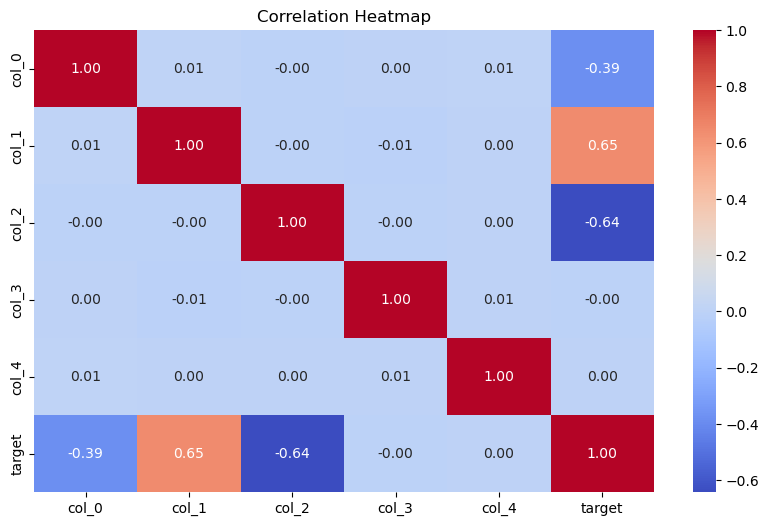

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df['col_0_cut'] = pd.qcut(df['col_0'], 8)

df.groupby(["col_0_cut"], as_index=False, observed=True)['target'].mean()

,col_0_cut,target
0,"(-3.889, -1.179]",270.930324
1,"(-1.179, -0.685]",259.528586
2,"(-0.685, -0.326]",253.807527
3,"(-0.326, -0.0171]",247.704563
4,"(-0.0171, 0.296]",243.658302
5,"(0.296, 0.66]",239.038320
6,"(0.66, 1.148]",233.175621
7,"(1.148, 5.007]",221.280789


C:\Users\kiera\AppData\Local\Temp\ipykernel_22248\3814985213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_0_cut', y='target', palette='viridis')


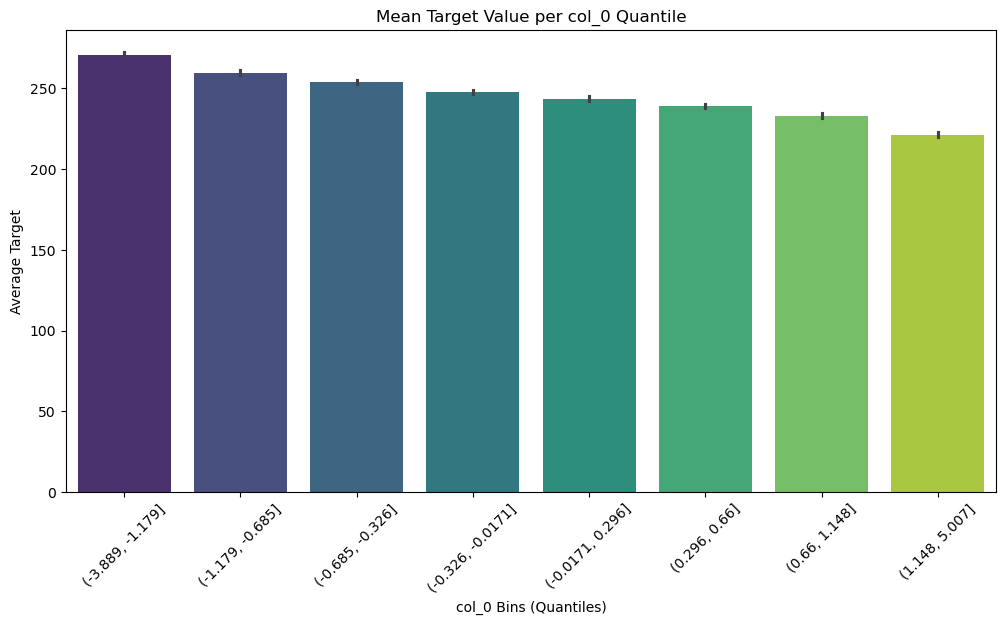

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_0_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_0 Quantile')
plt.xlabel('col_0 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

C:\Users\kiera\AppData\Local\Temp\ipykernel_22248\816166857.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_1_cut', y='target', palette='viridis')


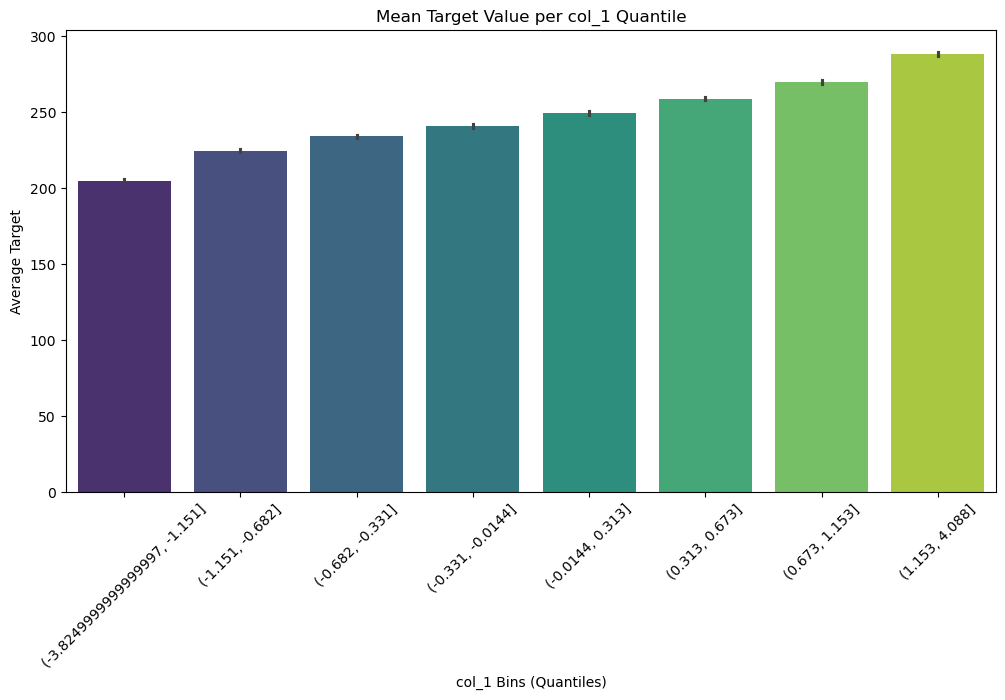

In [12]:
df['col_1_cut'] = pd.qcut(df['col_1'], 8)

df.groupby(["col_1_cut"], as_index=False, observed=True)['target'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_1_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_1 Quantile')
plt.xlabel('col_1 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

C:\Users\kiera\AppData\Local\Temp\ipykernel_22248\2371019045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_2_cut', y='target', palette='viridis')


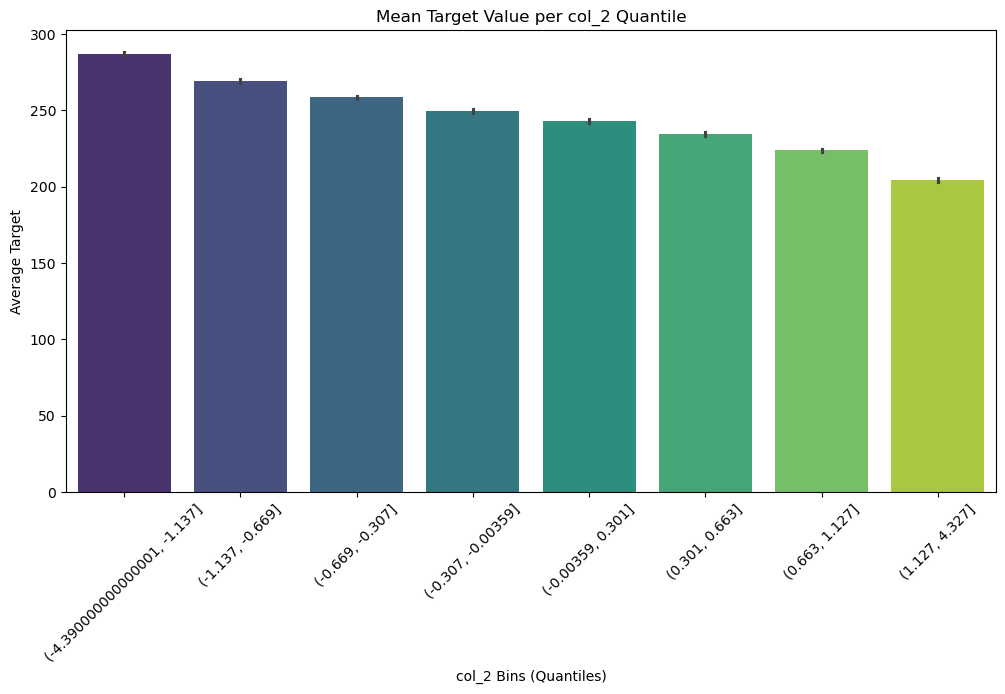

In [13]:
df['col_2_cut'] = pd.qcut(df['col_2'], 8)

df.groupby(["col_2_cut"], as_index=False, observed=True)['target'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_2_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_2 Quantile')
plt.xlabel('col_2 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

In [14]:
df["col_0_col_1_difference"] = df["col_0"] - df["col_1"]
df["col_1_col_2_difference"] = df["col_1"] - df["col_2"]

In [15]:
correlations = df.corr(numeric_only=True)['target']
print(correlations)

col_0                    -0.385041
col_1                     0.646885
col_2                    -0.642064
col_3                    -0.002781
col_4                     0.000560
target                    1.000000
col_0_col_1_difference   -0.733426
col_1_col_2_difference    0.910477
Name: target, dtype: float64


In [16]:
df["col_0_col_1_difference_div"] = df["col_0"] / df["col_1"]
df["col_1_col_2_difference_div"] = df["col_1"] / df["col_2"]
df["col_0_col_2_difference_div"] = df["col_0"] / df["col_2"]

In [17]:
correlations = df.corr(numeric_only=True)['target']
print(correlations)

col_0                        -0.385041
col_1                         0.646885
col_2                        -0.642064
col_3                        -0.002781
col_4                         0.000560
target                        1.000000
col_0_col_1_difference       -0.733426
col_1_col_2_difference        0.910477
col_0_col_1_difference_div   -0.007746
col_1_col_2_difference_div    0.008786
col_0_col_2_difference_div   -0.002599
Name: target, dtype: float64


In [18]:
from sklearn.linear_model import LinearRegression

X = df[['col_1_col_2_difference']]
y = df['target']
model = LinearRegression().fit(X, y)

df['leftover'] = y - model.predict(X)

print(df[['leftover', 'col_0']].corr())

          leftover     col_0
leftover  1.000000 -0.953452
col_0    -0.953452  1.000000


In [19]:
from sklearn.linear_model import LinearRegression
import numpy as np

df['diff_1_2'] = df['col_1'] - df['col_2']
X = df[['diff_1_2', 'col_0']]
y = df['target']

# 2. Fit the model to find the 'Secret Constants'
model = LinearRegression()
model.fit(X, y)

# 3. Extract the coefficients
A = model.coef_[0]
B = model.coef_[1]
intercept = model.intercept_

print(f"Detected Formula: Target = ({A:.2f} * (col_1 - col_2)) + ({B:.2f} * col_0) + {intercept:.2f}")

# 4. Check the Accuracy (R-squared)
r2 = model.score(X, y)
print(f"Formula Accuracy (R^2): {r2:.5f}")

Detected Formula: Target = (25.31 * (col_1 - col_2)) + (-15.32 * col_0) + 245.95
Formula Accuracy (R^2): 0.98446


In [20]:
df['prediction'] = (25.31 * (df['col_1'] - df['col_2'])) + (-15.32 * df['col_0']) + 245.95

df['final_error'] = df['target'] - df['prediction']

df['col_0_sq'] = df['col_0']**2
print(df[['final_error', 'col_0_sq', 'col_3', 'col_4']].corr()['final_error'])

final_error    1.000000
col_0_sq       0.002364
col_3          0.002334
col_4          0.014092
Name: final_error, dtype: float64


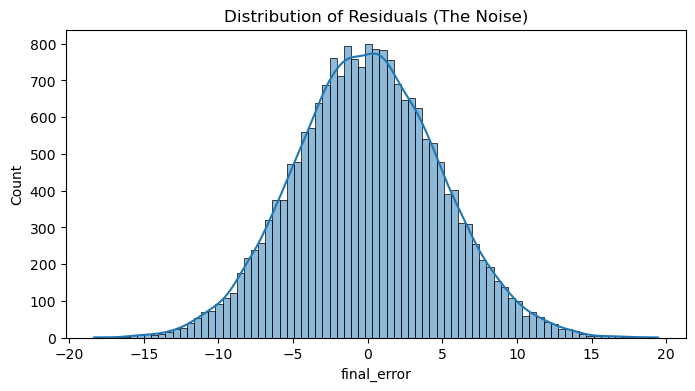

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['final_error'], kde=True)
plt.title('Distribution of Residuals (The Noise)')
plt.show()

In [22]:
import numpy as np

df['col_0_sq'] = df['col_0']**2
df['col_0_cube'] = df['col_0']**3

df['combo_0_1_2'] = df['col_0'] * df['diff_1_2']

df['abs_diff'] = np.abs(df['col_1'] - df['col_2'])

new_candidates = ['col_0_sq', 'col_0_cube', 'combo_0_1_2', 'abs_diff', 'col_3', 'col_4']
corrs = df[new_candidates].corrwith(df['final_error']).abs().sort_values(ascending=False)

print("Correlation with the remaining 1.6% error:")
print(corrs)

Correlation with the remaining 1.6% error:
combo_0_1_2    0.016656
col_4          0.014092
abs_diff       0.011641
col_0_sq       0.002364
col_3          0.002334
col_0_cube     0.000037
dtype: float64


In [23]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

df['diff_1_2'] = df['col_1'] - df['col_2']
features = ['diff_1_2', 'col_0']

X = df[features]
y = df['target']

final_model = Ridge(alpha=1.0) 
cv_scores = cross_val_score(final_model, X, y, cv=5, scoring='r2')

print(f"Stable Competition Score (R^2): {cv_scores.mean():.5f} (+/- {cv_scores.std():.5f})")

Stable Competition Score (R^2): 0.98445 (+/- 0.00020)


In [24]:
import numpy as np

# Test different transformations of col_0 against the leftover
df['col_0_sq'] = df['col_0']**2
df['col_0_sqrt'] = np.sqrt(df['col_0'].clip(lower=0)) # clip to avoid NaNs
df['col_0_abs'] = df['col_0'].abs()

# Check correlations again
test_cols = ['col_0', 'col_0_sq', 'col_0_sqrt', 'col_0_abs']
print(df[test_cols].corrwith(df['leftover']))

col_0        -0.953452
col_0_sq      0.023829
col_0_sqrt   -0.850451
col_0_abs     0.017439
dtype: float64


In [25]:
# 1. Calculate the Standard Deviation of your leftovers (the noise)
noise_std = df['leftover'].std()

# 2. Create your prediction
df['base_prediction'] = (25.31 * (df['col_1'] - df['col_2'])) + (-15.32 * df['col_0']) + 245.95

# 3. Create the 'Confidence Spread' (95% confidence)
df['lower_bound'] = df['base_prediction'] - (2 * noise_std)
df['upper_bound'] = df['base_prediction'] + (2 * noise_std)

print(f"The average 'wiggle room' for the target is +/- {2 * noise_std:.2f}")

The average 'wiggle room' for the target is +/- 32.30


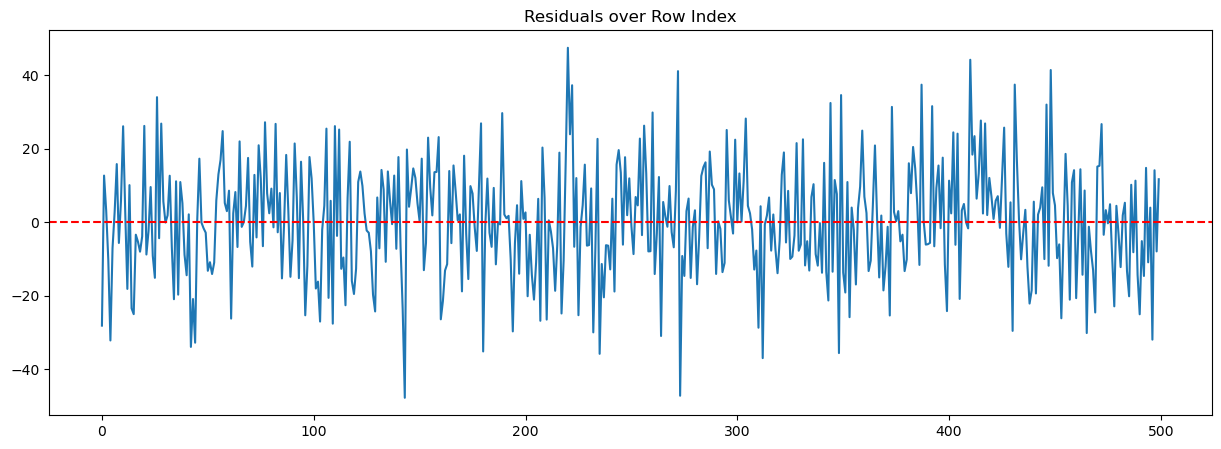

In [26]:
plt.figure(figsize=(15, 5))
plt.plot(df['leftover'].iloc[:500]) # Look at the first 500 rows
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals over Row Index')
plt.show()